In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import os  
import glob
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 1.4 #set the value globally

from lmfit import Model
plt.style.use('properties.mplstyle')
from scipy.stats import kstest

In [23]:
N = [25000, 50000, 75000, 100000, 125000, 150000, 175000, 200000]
alpha_a = 2.0
alpha_g = 2.0
m = 2
dim = 4
# The processor clock speed was set at 4.0 GHz.
complexity_time = [ ]
for i in N:
    path_all = f"../../data/N_{i}/m0_{m}/dim_{dim}/alpha_a_{alpha_a:.2f}_alpha_g_{alpha_g:.2f}/time_process_seconds.txt"

    data = pd.read_csv(path_all)
    time_mean = data.mean().values[0]
    complexity_time.append(time_mean)
    

[[Model]]
    Model(time_theoric)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 252
    # data points      = 8
    # variables        = 2
    chi-square         = 16593.3076
    reduced chi-square = 2765.55126
    Akaike info crit   = 65.0985055
    Bayesian info crit = 65.2573886
    R-squared          = 0.98140385
[[Variables]]
    q:  1.65582269 +/- 0.14277343 (8.62%) (init = 7.72e-08)
    b:  1.7326e-06 +/- 2.9775e-06 (171.85%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(q, b) = -0.9998
KS Statistic: 0.125
P-value: 1.0


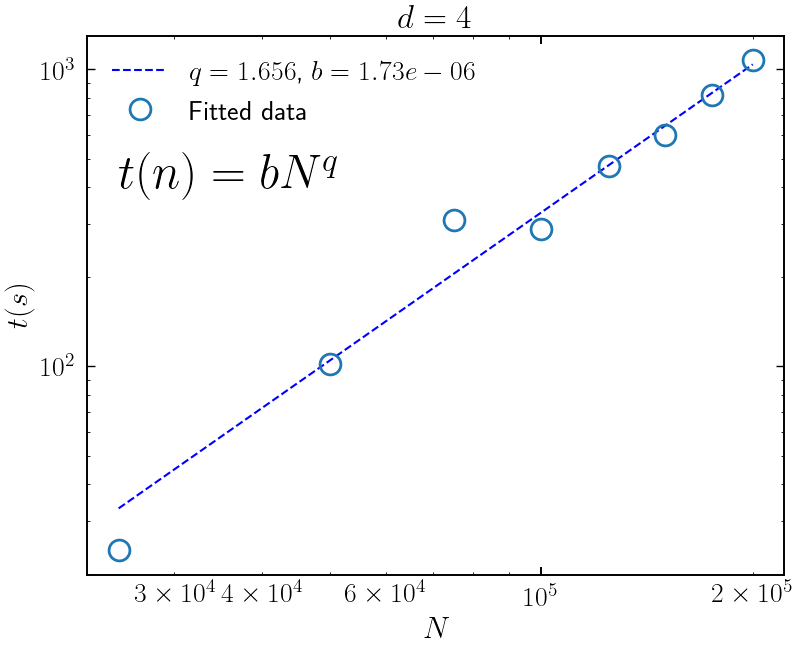

In [40]:
y = complexity_time

# Set parameters for the q-exponential distribution
#q_p = 0.00003
q_init = 1.93/(5000**2)
b_init = 1/2
#b_parameter = kappa(alpha_a, dim)

# q_parameter = 1.3
# b_parameter = 0.415

def time_theoric(x, q, b):
    real_distri = []
    for i in range(len(x)):
        term = b*x[i]**q
        real_distri.append(term)
    
    return real_distri
    
# Create a model using the custom q-exponential function
model = Model(time_theoric)

# Set initial parameter values
params = model.make_params(q=q_init, b=b_init)

# Fit the model to the truncated data
result = model.fit(y, params, x=N)

# Get the fitted parameters
fitted_q= result.params['q'].value
fitted_b = result.params['b'].value

#real_data = exp(N,fitted_q_1d)
# Perform KS test on the fitted q-exponential distribution using the CDF
ks_statistic, ks_p_value = kstest(y, time_theoric(N, fitted_q, fitted_b))

# Display the results
print(result.fit_report())
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {ks_p_value}")
#plt.plot(k_trunc, q_exp(k_trunc, fitted_q, fitted_b), 'b--', label='Fitted q-Exponential')
fig, ax = plt.subplots(figsize=(9, 7))
mew = 2.0
ms = 15
ax.plot(N, time_theoric(N, fitted_q, fitted_b), 'b--', label=f'$q = {fitted_q:.3f}$, $b={fitted_b:.2e}$')

ax.plot(N, y, "o", mew=mew, ms=ms, label='Fitted data')
ax.text(25000, 10**2.6, r"$t(n) = bN^q$", fontsize=35)
ax.set_title(f"$d = {dim}$")
ax.set_xlabel(r"$N$",fontsize=22)
ax.set_ylabel(r"$t(s)$",fontsize=22)
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
plt.show()

In [17]:
def expect_value(N, count_time, just_value):    
    a, b = fitted_q, fitted_b
    
    if(count_time == 'seconds'):
        if(just_value==False):
            return print(f"time to {int(N)} nodes is {b*N**a} seconds")
        else:
            return b*N**a
    elif(count_time == 'minutes'):
        if(just_value==False):
            return print(f"time to {int(N)} nodes is {b*N**a/60} minutes")
        else:
            return b*N**a/60
    elif(count_time == 'hours'):
        if(just_value==False):
            return print(f"time to {int(N)} nodes is {b*N**a/3600} hours")
        else:
            return b*N**a/3600
    elif(count_time == 'days'):
        if(just_value==False):
            return print(f"time to {int(N)} nodes is {b*N**a/(24*3600)} days")
        else:
            return b*N**a/(24*3600)
    #return print(f"time to {N} nodes is {b*N**a/60} minutes, {b*N**a/3600} hours, {b*N**a/(24*3600)} days")

In [18]:
time_single_sample = []
number_N = [160000]

type_time = "hours"

for i in range(len(number_N)):
    c_1 = expect_value(N=number_N[i],count_time=type_time,just_value=True)
    time_single_sample.append(c_1)
#c_2 = expect_value(N=10**5,dim=1,count_time='days',just_value=True)

In [19]:
alpha_a = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
alpha_g = [0.1, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
dim = [1 ,2, 3, 4]
num_variables = len(alpha_a)*len(alpha_g)*len(dim)
t_s = [num_variables*i for i in time_single_sample]
n_samples = 5
f"N = {number_N[0]}, {(t_s[0]*n_samples)/20} {type_time} to {n_samples} samples" 
#(t_s[1]*25)/20
#num_variables

'N = 160000, 19.929379003426135 hours to 5 samples'

In [ ]:
N_estimative = 250000
expect_value(N=N_estimative, count_time='hours',just_value=False)

time to 250000 nodes is 0.4172778801822009 hours


In [11]:
c_1

1.4609394675301204

In [12]:
alpha_a_1 = np.arange(0.1,1,.1)
alpha_a_2 = np.arange(4.5,9.5,1)
alpha_a = np.concatenate((alpha_a_1,alpha_a_2),axis=0)
dim = [1,2,3,4]
N_s = 78
T_t = len(dim)*len(alpha_a)*N_s*c_1
print((T_t/20)/24)

13.294549154524097


The complexity_time to run growth with power law

$O(N^2)$,

specificaly

$t = bN^q$,

where $t$ the time to run code (in seconds), $N$ the size of nodes, with $b$ of the order $10^{-8}$ and $q \approx 2$.